In [3]:
# Pair, linked-list, and Source Academy compatibility helpers are defined here.

import math

class Pair(tuple):
    """A Source Academy-style pair that also supports head/tail selectors."""

    def __new__(cls, head_value, tail_value):
        return super().__new__(cls, (head_value, tail_value))

    def __call__(self, selector):
        return selector(self[0], self[1])


def pair(head_value, tail_value):
    return Pair(head_value, tail_value)


def head(p):
    return p(lambda head_value, tail_value: head_value)


def tail(p):
    return p(lambda head_value, tail_value: tail_value)


def is_none(value):
    return value is None


def is_pair(value):
    return isinstance(value, Pair)


def llist(*values):
    result = None
    for value in reversed(values):
        result = pair(value, result)
    return result


def is_llist(value):
    current = value
    while is_pair(current):
        current = tail(current)
    return is_none(current)

def enum_llist(start, end):
    result = None
    for value in range(end, start - 1, -1):
        result = pair(value, result)
    return result

def print_llist(xs):
    values = []
    while not is_none(xs):
        values.append(str(head(xs)))
        xs = tail(xs)
    print(f"llist({', '.join(values)})")

def length(xs):
    return 0 if is_none(xs) else 1 + length(tail(xs))

def append(xs, ys):
    return (ys 
            if is_none(xs)
            else pair(head(xs), append(tail(xs), ys)))

def map(f, xs):
    return (None
            if is_none(xs)
            else pair(f(head(xs)), map(f, tail(xs))))

def filter(pred, xs):
    return (None
            if is_none(xs)
            else pair(head(xs), filter(pred, tail(xs)))
                if pred(head(xs))
                else filter(pred, tail(xs)))

def reduce(op, initial, xs):
    return (initial
            if is_none(xs)
            else op(head(xs), reduce(op, initial, tail(xs))))


details! <br>
All core material up to and including Week 5's Lectures, Paths, Missions, Reflections, Studios. <br>
probably includes curves & sound so gotta study allat... <br>

basically im gna make the cheatsheet here and copy paste from here later.

# PRACTICE A

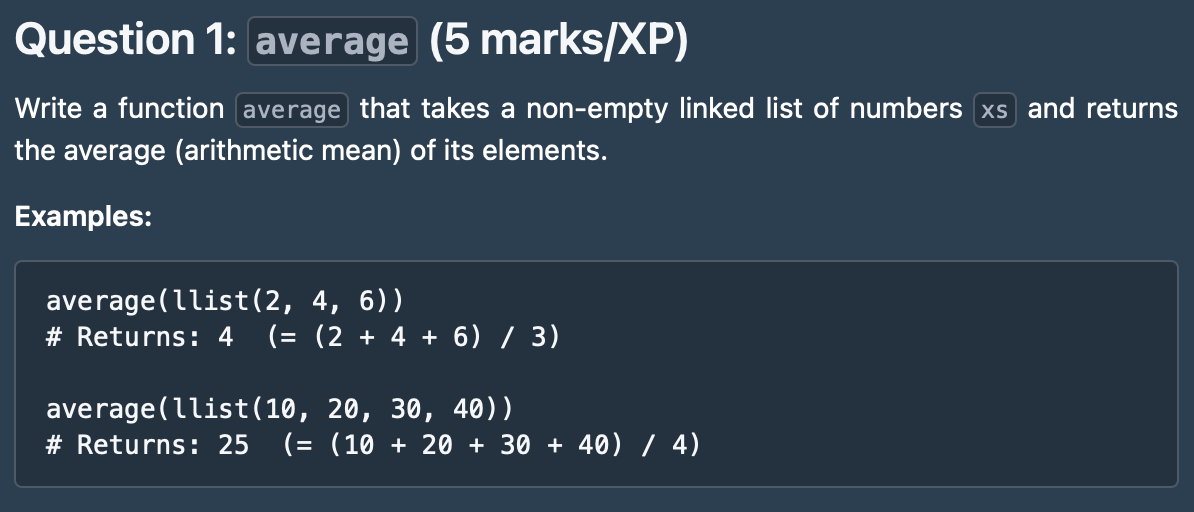

ok i fucking hate telling him hes smart and feeding his ego but this was smart only <br>
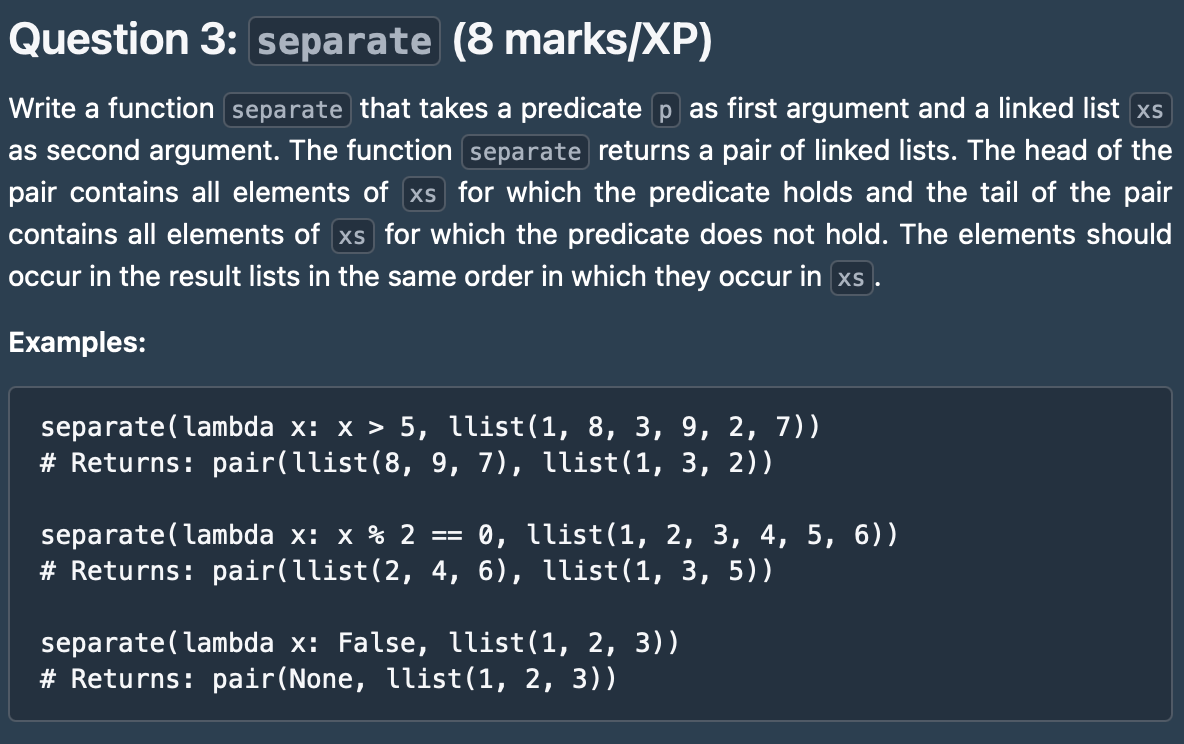

In [4]:
# my solution
def helper(x, ys): #want to check if am element x is not in ys
    if is_none(ys): return True
    elif x==head(ys): return False
    else: return helper(x, tail(ys))
    
def separate(p, xs):
    head = filter(p, xs)
    tail = filter(lambda x: helper(x, head), xs) #check if not in head
    return pair(head, tail)

# alternative solution (nandan's) (stfu this guy is too cracked im killing myself)

def separate2(p, xs):
    def helper2(fulfils, doesnt, p, xs): 
        if is_none(xs): 
            return pair(fulfils, doesnt)
        elif p(head(xs)): 
            return helper2(append(fulfils, llist(head(xs))), doesnt, p, tail(xs))
        else:
            return helper2(fulfils, append(doesnt, llist(head(xs))), p, tail(xs))
    return helper2(None, None, p, xs)

# Practical Exam 1
went horribly btw. i had 70mis for last 3 qns and cldnt solve them...
gna try them again rn

##### Qn 7: `count_sale_below` (8 marks)
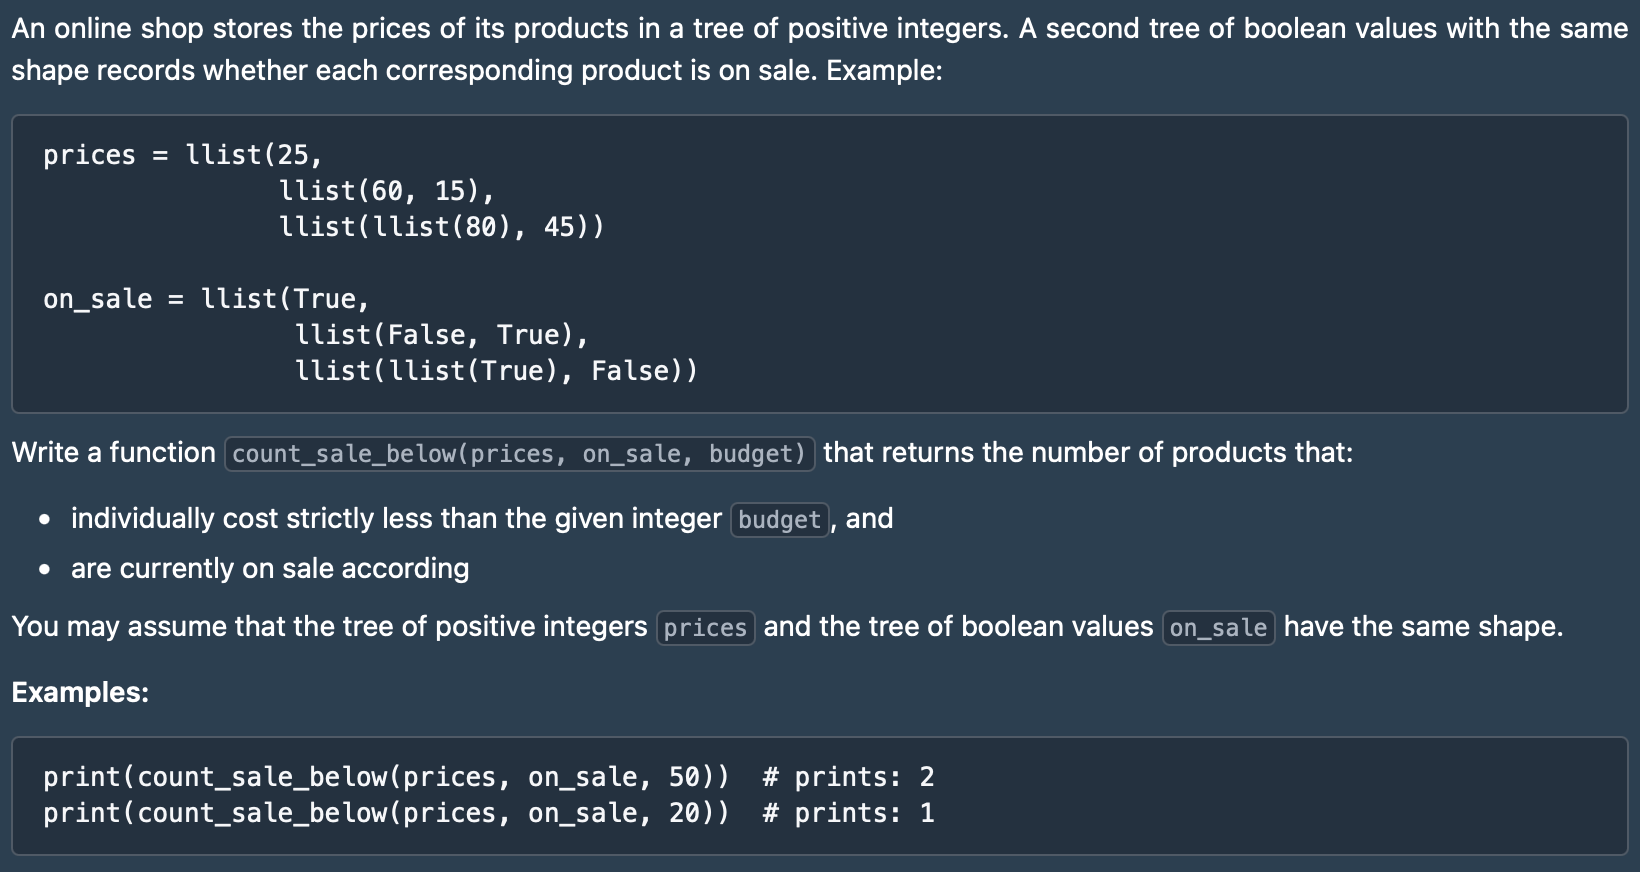

In [14]:
def count_sale_below(prices, onsale, budget):
    if is_none(prices): 
        return 0
    elif is_llist(head(prices)): 
        return count_sale_below(head(prices), head(onsale), budget) + count_sale_below(tail(prices), tail(onsale), budget)
    elif head(prices) < budget and head(onsale)==True:
        return 1+ count_sale_below(tail(prices), tail(onsale), budget)
    else: 
        return count_sale_below(tail(prices), tail(onsale), budget)

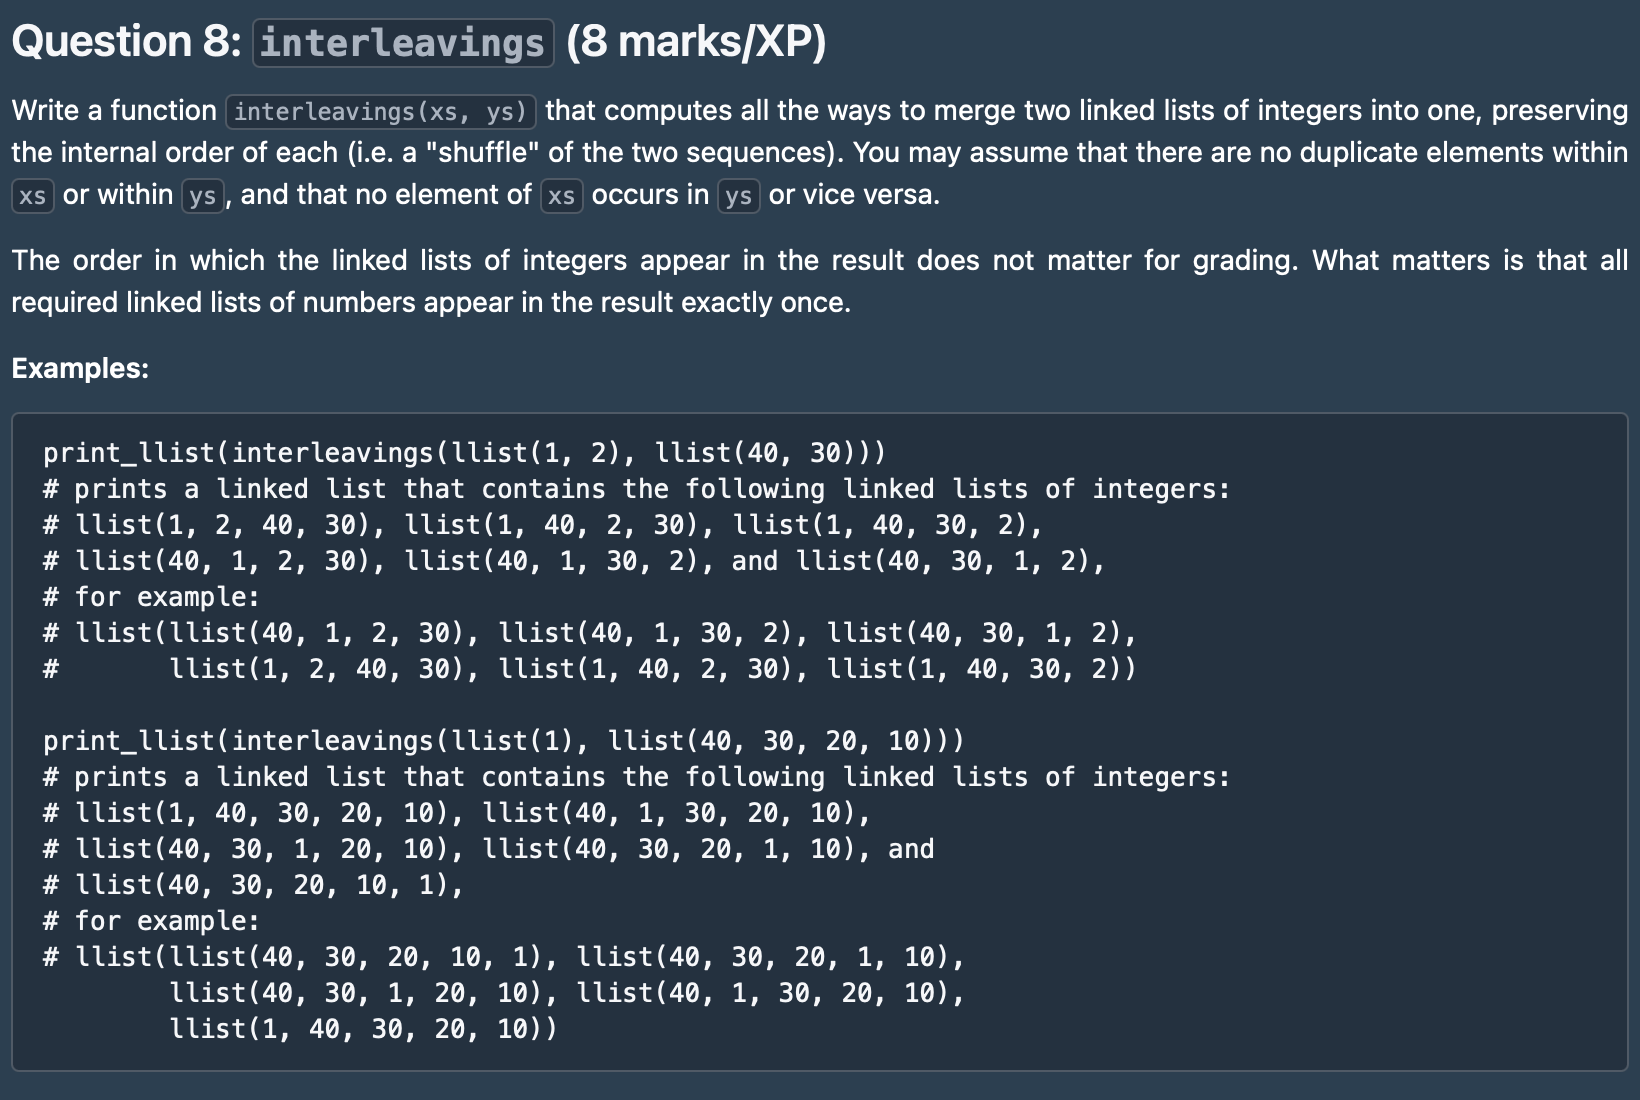

In [20]:
# wish that u knew all the combis of tail xs and whole ys
# so interleavings(tail(xs), ys)
# now u wanna add head to the front of each of these. 
# use map? map(f, xs) where f = lambda x: pair(head(xs), x), xs = interleavings(tail(xs), ys)
# now for base cases...
# if xs is none -> only look at combi b. 
# if ys is none -> only look at combi a
# if both none -> return None

def interleavings(xs, ys):
    if is_none(xs) and is_none(ys): return llist(None)
    elif is_none(xs):
        return map(lambda x: pair(head(ys), x), interleavings(xs, tail(ys)))
    elif is_none(ys):
        return map(lambda x: pair(head(xs), x), interleavings(tail(xs), ys))
    else:
        combi_a = map(lambda x: pair(head(xs), x), interleavings(tail(xs), ys))
        combi_b = map(lambda x: pair(head(ys), x), interleavings(xs, tail(ys)))
        return append(combi_a, combi_b)

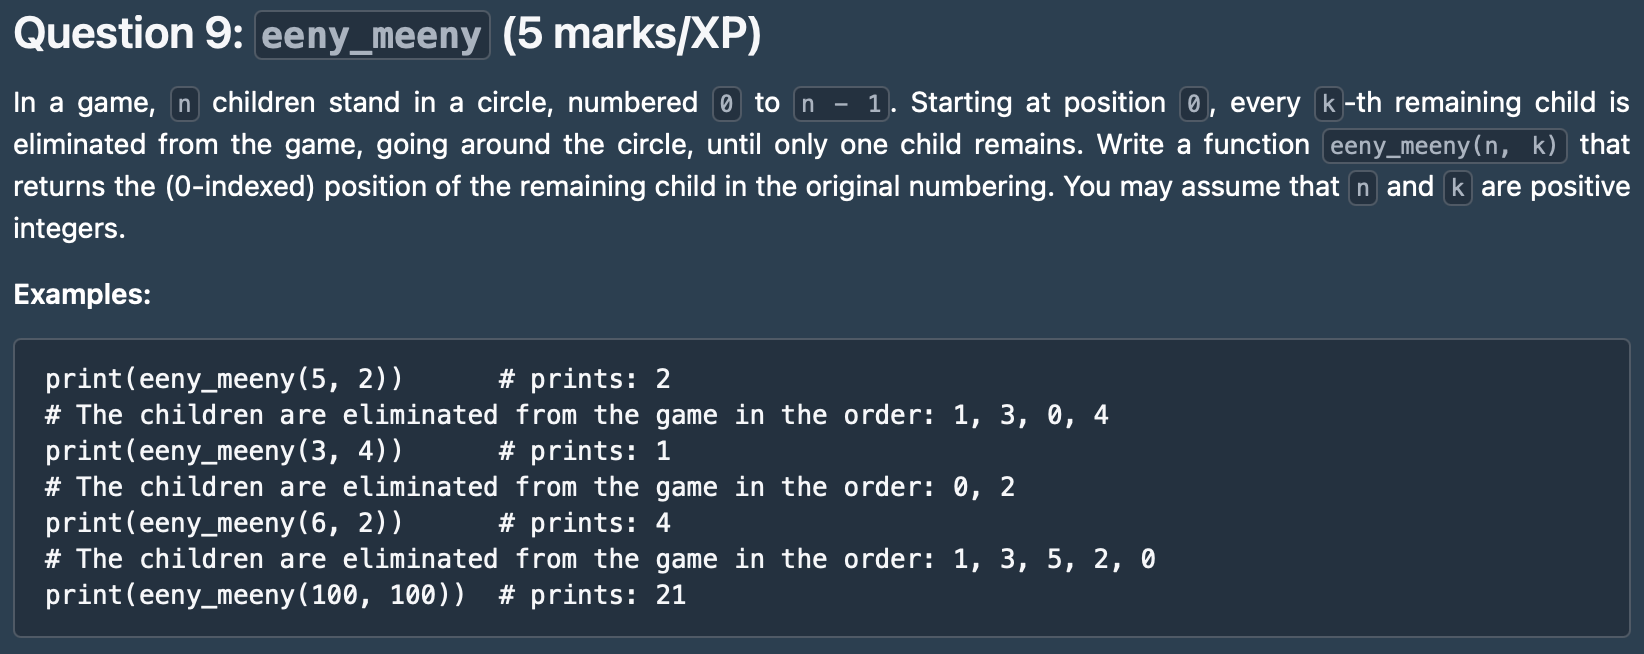

In [ ]:
# counter = 1 initially
# check if counter = k -> if yes -> (1) return tail (2) reset counter to 1
#                      -> if not -> (1) remove head and append to the back (2) counter +1
# base case is when llist only has one element -> aka tail is None -> then return head

def eeny_meeny(n, k):
    def create_llist(n, x):
        if x==n: 
            return None
        else: 
            return pair(x, create_llist(n, x+1))

    def helper(xs, k, counter):
        if is_none(tail(xs)): return head(xs)
        elif counter==k:
            return helper(tail(xs), k, 1)
        else:
            new_list = append( tail(xs), llist(head(xs)) )
            return helper(new_list, k, counter+1)

    return helper(create_llist(n, 0), k, 1)

4